In [ ]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
from tqdm import tqdm
import librosa
import matplotlib.pyplot as plt
import librosa.display
from tensorflow.keras import layers, models
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

In [ ]:
def create_melspectrogram(segmented_dir, all_categories, n_mels=128):
    segmented_dir = Path(segmented_dir)
    X = []
    y = []
    labels = [f.name for f in segmented_dir.iterdir() if f.is_dir()]

    for label in tqdm(labels):
        for audio in (segmented_dir / label).iterdir():
            if audio.suffix == ".wav":
                signal, sr = librosa.load(audio, sr=None)
                melspectrogram = librosa.feature.melspectrogram(y=signal, 
                                                        sr=sr, 
                                                        n_mels=n_mels, 
                                                        fmax=sr/2)
                melspectrogram_db = librosa.power_to_db(melspectrogram, ref=np.max)
                X.append(melspectrogram_db)
                y.append(label)
            
    X = np.array(X)
    X = np.expand_dims(X, axis=-1)

    label_encoder = LabelEncoder()
    y = label_encoder.fit_transform(y)

    return X, np.array(y), label_encoder

Import data for model

In [ ]:
X, y, label_encoder = create_melspectrogram('segmented')

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=1)

1847it [01:32, 19.94it/s]
790it [00:31, 25.19it/s]


Plot mel spectrogram

In [10]:
def plot_melspectrogram(X, i):
    melspectrogram_sample = X[i, :, :, 0]
    librosa.display.specshow(melspectrogram_sample, x_axis='time', y_axis='mel', cmap='viridis')
    plt.colorbar(label='Amplitude')
    plt.title('Mel Spectrogram')
    plt.xlabel('Time Frames')
    plt.ylabel('Mel Frequency Bands')
    plt.show()

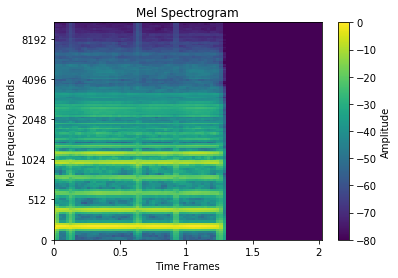

In [ ]:
plot_melspectrogram(X_train)

CNN model

In [ ]:
cnn = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(X.shape[1], X.shape[2], 1)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2), padding='same'),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2), padding='same'),
    layers.Dropout(0.25),

    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2), padding='same'),
    layers.Dropout(0.25),

    layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2), padding='same'),
    layers.Dropout(0.25),

    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(len(np.unique(y)), activation='softmax')
])

cnn.compile(optimizer='adam',
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy'])

cnn.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d (Conv2D)              (None, 128, 87, 32)       320       
_________________________________________________________________
max_pooling2d (MaxPooling2D) (None, 64, 44, 32)        0         
_________________________________________________________________
dropout (Dropout)            (None, 64, 44, 32)        0         
_________________________________________________________________
conv2d_1 (Conv2D)            (None, 64, 44, 64)        18496     
_________________________________________________________________
max_pooling2d_1 (MaxPooling2 (None, 32, 22, 64)        0         
_________________________________________________________________
dropout_1 (Dropout)          (None, 32, 22, 64)        0         
_________________________________________________________________
conv2d_2 (Conv2D)            (None, 32, 22, 128)       7

Train CNN

In [ ]:

cnn.fit(X_train, y_train, epochs=60)

Epoch 1/60
235/235 [==============================] - 38s 164ms/step - loss: 2.8558 - accuracy: 0.1829
Epoch 2/60
235/235 [==============================] - 38s 162ms/step - loss: 2.1568 - accuracy: 0.2758
Epoch 3/60
235/235 [==============================] - 38s 160ms/step - loss: 1.8054 - accuracy: 0.3971
Epoch 4/60
235/235 [==============================] - 37s 157ms/step - loss: 1.5285 - accuracy: 0.4895
Epoch 5/60
235/235 [==============================] - 37s 157ms/step - loss: 1.3441 - accuracy: 0.5657
Epoch 6/60
235/235 [==============================] - 37s 157ms/step - loss: 1.1798 - accuracy: 0.6252
Epoch 7/60
235/235 [==============================] - 36s 154ms/step - loss: 1.0173 - accuracy: 0.6741
Epoch 8/60
235/235 [==============================] - 35s 149ms/step - loss: 0.9411 - accuracy: 0.7110
Epoch 9/60
235/235 [==============================] - 35s 150ms/step - loss: 0.8441 - accuracy: 0.7378
Epoch 10/60
235/235 [==============================] - 37s 156ms/step - l

Evaluate CNN

In [ ]:
y_pred = cnn.predict(X_test)
y_pred = np.argmax(y_pred, axis=1)

y_pred_labels = label_encoder.inverse_transform(y_pred)
y_test_labels = label_encoder.inverse_transform(y_test)

accuracy = accuracy_score(y_test_labels, y_pred_labels)
class_report = classification_report(y_test_labels, y_pred_labels)

print('Accuracy:', accuracy)
print('\nClassification Report:\n', class_report)

# output_file = 'cnn_melspectrogram_evaluation.txt'

# with open(output_file, 'w') as file:
#     file.write(f'Accuracy: {accuracy}\n')
#     file.write('\nClassification Report:\n')
#     file.write(class_report)

# best .809

Accuracy: 0.80980271270037

Classification Report:
                   precision    recall  f1-score   support

 Acoustic_guitar       0.91      0.81      0.86       215
       Bass_drum       0.88      0.30      0.44        47
           Cello       0.88      0.69      0.78        55
        Clarinet       0.58      0.80      0.68        86
         Cowbell       0.69      0.76      0.72       123
     Double_bass       0.63      0.63      0.63       154
  Electric_piano       0.88      0.83      0.85       681
           Flute       0.86      0.94      0.90       353
    Glockenspiel       0.78      0.82      0.80       328
       Harmonica       0.93      0.94      0.94        71
          Hi-hat       0.63      0.61      0.62       175
            Oboe       0.91      0.67      0.77       189
       Saxophone       0.97      0.97      0.97        35
      Tambourine       0.90      0.71      0.80        52
         Trumpet       0.82      0.78      0.80       245
Violin_or_fiddle   

Save CNN

In [ ]:
# cnn.save('cnn_melspectrogram_model.h5')